<font face="B Nazanin" size=8>
<div dir=rtl align=center>
<br>
<img src="https://aut.ac.ir/templates/tmpl_modern01/images/logo_fa.png" alt="Amirkabir University Logo" width="100">
<br>
<font size=6>
<b>پروژه اول داده کاوی</b>
<br>
<font size=5> استاد درس: دکتر فاطمه شاکری
<br>
<font size=5> طراحان پروژه: پویا برازنده، پارسا محبیان، ایمان حسن‌خانی
<br>
<font size=4> بهار ۱۴۰۵
<hr>
</div>
</font>

<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=5><font color='#eb4034'>
توجه داشته باشید علاوه بر پیاده سازی‌های خواسته شده، توضیحات لازم را در محل تعریف شده بیان کنید.
</p>
</font>
</div>
</font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# برای رسم نمودار‌های واضح‌تر، خط زیر را آنکامنت کنید
# %config InlineBackend.figure_formats = ['svg']

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
بارگذاری مجموعه داده


In [2]:
data = pd.read_csv('../data/apartment_rent.csv')
data.head()

,title,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude,source,time
0,Thomas Ninke Senior Village,"AC,Cable or Satellite,Clubhouse,Dishwasher,Gat...",1.0,1.0,No,Thumbnail,"Cats,Dogs",337.0,617,Victoria,TX,28.696040,-97.164089,RentDigs.com,1547715453
1,"Average Rent $1,284 a month - That's a STEAL. ...","Parking,Patio/Deck,Pool,Washer Dryer",1.0,1.0,No,Yes,"Cats,Dogs",1284.0,728,Dallas,TX,32.851338,-96.817635,RentDigs.com,1568757960
2,Super Cute! Apartment for Rent. $923/mo,"Fireplace,Gym,Pool,Tennis,Washer Dryer",1.0,1.0,No,Thumbnail,"Cats,Dogs",923.0,510,Richmond,VA,37.530061,-77.476208,RentDigs.com,1568744171
3,Apartment in move in condition in Loganville,NaN,2.0,4.0,No,Yes,NaN,1595.0,1950,Loganville,GA,33.795894,-83.877143,RentDigs.com,1568777003
4,"$2,000 / Three BR - Great Deal. MUST SEE!","Dishwasher,Garbage Disposal,Parking,Refrigerat...",2.0,3.0,No,Yes,"Cats,Dogs",2000.0,1600,Chicago,IL,42.005037,-87.681448,RentDigs.com,1544237300


<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
پیش پردازش
</font>
</h2>

<div dir=rtl>
<font face="B Nazanin" size=4>
ابعاد داده را چاپ کنید.
</font>
</p>



In [3]:
print("Dimensions of dataset:", data.shape)

Dimensions of dataset: (99788, 15)



<div dir=rtl>
<font face="B Nazanin" size=4>
رکوردهای تکراری را در مجموعه داده بررسی کنید و درصورت نیاز حذف کنید.
</font>
</p>

In [4]:
# show duplicates
print('Number of duplicates:', data.duplicated().sum())

Number of duplicates: 86


In [5]:
# if there are duplicates, drop them
data = data.drop_duplicates()
print("Number of new distinct records:", data.shape[0])

Number of new distinct records: 99702


<div dir=rtl>
<font face="B Nazanin" size=4>
در حال حاضر ویژگی <code>title</code> ارزش اطلاعاتی ندارد، این ستون را حذف کنید.

</font>
</p>

In [6]:
data = data.drop('title', axis=1)
data.head()

,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude,source,time
0,"AC,Cable or Satellite,Clubhouse,Dishwasher,Gat...",1.0,1.0,No,Thumbnail,"Cats,Dogs",337.0,617,Victoria,TX,28.696040,-97.164089,RentDigs.com,1547715453
1,"Parking,Patio/Deck,Pool,Washer Dryer",1.0,1.0,No,Yes,"Cats,Dogs",1284.0,728,Dallas,TX,32.851338,-96.817635,RentDigs.com,1568757960
2,"Fireplace,Gym,Pool,Tennis,Washer Dryer",1.0,1.0,No,Thumbnail,"Cats,Dogs",923.0,510,Richmond,VA,37.530061,-77.476208,RentDigs.com,1568744171
3,NaN,2.0,4.0,No,Yes,NaN,1595.0,1950,Loganville,GA,33.795894,-83.877143,RentDigs.com,1568777003
4,"Dishwasher,Garbage Disposal,Parking,Refrigerat...",2.0,3.0,No,Yes,"Cats,Dogs",2000.0,1600,Chicago,IL,42.005037,-87.681448,RentDigs.com,1544237300


<div dir=rtl>
<font face="B Nazanin" size=4>
 مقادیر گمشده را در مجموعه داده بررسی کنید.
</font>
</p>

In [7]:

missing = data.isnull().sum()

# Print the number of NaNs in each column
print("Number of NaN values in each column:")
print(missing)

Number of NaN values in each column:
amenities       16049
bathrooms          61
bedrooms          122
fee                 0
has_photo           0
pets_allowed    60544
price               1
square_feet         0
cityname          302
state             302
latitude           25
longitude          25
source              0
time                0
dtype: int64


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>مدیریت مقادیر گم‌شده</b>
</font>
</h4>
<div dir=rtl>
<font face="B Nazanin" size=4>
ستون <code>amenities</code> که نشان‌دهنده‌ی امکانات رفاهی خانه‌ها است، مقادیر گم‌‌شده‌ی بسیار زیادی دارد. 
در مورد این ویژگی خاص، نمی‌توان قضاوت نمود که آیا مقادیر واقعا گم‌شده هستند یا اینکه هیچ‌گونه امکانات رفاهی برای یک آگهی ثبت نشده است.
به هر حال مقادیر گم‌شده این ویژگی را با مقدار <code>'none advertised'</code> جایگزین کنید.
<br>
ستون <code>pets_allowed</code> نیز وضعیت مشابهی با ستون <code>amenities</code> دارد. مقادیر گم‌شده این ستون را با مقدار پیش‌فرض <code>No</code>
جایگزین کنید.  </font>
</p>

In [8]:

data['amenities'] = data['amenities'].fillna('none advertised')

data['pets_allowed'] = data['pets_allowed'].fillna('No')

<div dir=rtl>
<font face="B Nazanin" size=4>
مقادیر گم‌شده ستون‌های <code>bathrooms</code> و <code>bedrooms</code> را قصد داریم با یکی از سه معیار آماری میانگین، میانه یا مد ستون‌ها پر کنیم.
<br>
</font>
</p>

<div dir=rtl>
<font face="B Nazanin" size=4>
به نظر شما کدام معیار آماری برای پر کردن مقادیر گم‌شده این ستون‌ها مناسب است؟ چرا؟
در ادامه با معیار گفته شده مقادیر گم‌شده را پر کنید.
<br>
</font>
</p>

In [9]:
data['bathrooms'] = data['bathrooms'].fillna(data['bathrooms'].median())
data['bedrooms'] = data['bedrooms'].fillna(data['bedrooms'].median())

<div dir=rtl>
<font face="B Nazanin">
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b>    
با توجه به اینکه bedrooms , bathroomsمتغیر های عددی گسسته هستند و احتمال وجود داده های پرت در آن ها وجود دارد استفاده از میانگین مناسب نیست زیرا میانگین تحت تاثیر داده های پرت 
    قرار میگیرد مد نیر به دلیل آنکه تنوع داده ها بالا است و ممکن است در لبه توزیع قرار داشته باشد مناسب نمیباشد اما میانه چون همواره در مرکز توزیع قرار دارد میتواند برای پر کردن مقادیر گم شده این ستون ها مقدار مناسبی باشد 
</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<font face="B Nazanin" size=4>
پس از آن سطرهایی که مقدار <code>cityname</code> یا <code>latitude</code> یا <code>price</code> آن‌ها خالی است را حذف کنید.
</font>
</p>

In [10]:
data = data.dropna(subset=['cityname', 'latitude', 'price'])

<div dir=rtl>
<font face="B Nazanin" size=4>
حال در صورتی که به درستی بخش‌های قبلی را انجام داده باشید، دیتافریم باید 99399 سطر داشته باشد و هیچ مقدار گم‌شده‌ای نداشته باشیم. با متد <code>()info</code> اطلاعات دیتافریم را بررسی کنید.
</font>
</p>

In [11]:
data.info()

<class 'pandas.DataFrame'>
Index: 99399 entries, 0 to 99787
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amenities     99399 non-null  str    
 1   bathrooms     99399 non-null  float64
 2   bedrooms      99399 non-null  float64
 3   fee           99399 non-null  str    
 4   has_photo     99399 non-null  str    
 5   pets_allowed  99399 non-null  str    
 6   price         99399 non-null  float64
 7   square_feet   99399 non-null  int64  
 8   cityname      99399 non-null  str    
 9   state         99399 non-null  str    
 10  latitude      99399 non-null  float64
 11  longitude     99399 non-null  float64
 12  source        99399 non-null  str    
 13  time          99399 non-null  int64  
dtypes: float64(5), int64(2), str(7)
memory usage: 11.4 MB


<div dir=rtl>
<font face="B Nazanin" size=4>
ویژگی 
<code>time</code>
به فرمت Unix Time ذخیره شده است که نوع دادهٔ مناسبی برای تحلیل سایر ویژگی‌ها بر اساس تاریخ نیست.
ابتدا آن را به قالبی مناسب در آوردیم.
<br>

</font>
</p>

In [12]:
data['time'] = pd.to_datetime(data['time'], unit='s')
data.head()

,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude,source,time
0,"AC,Cable or Satellite,Clubhouse,Dishwasher,Gat...",1.0,1.0,No,Thumbnail,"Cats,Dogs",337.0,617,Victoria,TX,28.696040,-97.164089,RentDigs.com,2019-01-17 08:57:33
1,"Parking,Patio/Deck,Pool,Washer Dryer",1.0,1.0,No,Yes,"Cats,Dogs",1284.0,728,Dallas,TX,32.851338,-96.817635,RentDigs.com,2019-09-17 22:06:00
2,"Fireplace,Gym,Pool,Tennis,Washer Dryer",1.0,1.0,No,Thumbnail,"Cats,Dogs",923.0,510,Richmond,VA,37.530061,-77.476208,RentDigs.com,2019-09-17 18:16:11
3,none advertised,2.0,4.0,No,Yes,No,1595.0,1950,Loganville,GA,33.795894,-83.877143,RentDigs.com,2019-09-18 03:23:23
4,"Dishwasher,Garbage Disposal,Parking,Refrigerat...",2.0,3.0,No,Yes,"Cats,Dogs",2000.0,1600,Chicago,IL,42.005037,-87.681448,RentDigs.com,2018-12-08 02:48:20


<div dir=rtl>
<font face="B Nazanin" size=4>
هر یک از مقادیر روز هفته، ماه و سال را از ویژگی
<code>time</code>
استخراج کنید و در یک ستون جداگانه قرار دهید تا بتوانیم تحلیل هایی در ارتباط با تاریخ در ادامه انجام دهیم.
<br>
درنهایت ستون
<code>time</code>
را حذف کنید.

</font>
</p>

In [13]:
# extract the Year out of the date
data['year'] = data['time'].dt.year

# extract the month out of the date
data['month'] = data['time'].dt.month

# extract the day out of the date
data['day_of_week'] = data['time'].dt.dayofweek
# Drop the 'time' column
data = data.drop('time', axis=1)

data.head()

,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude,source,year,month,day_of_week
0,"AC,Cable or Satellite,Clubhouse,Dishwasher,Gat...",1.0,1.0,No,Thumbnail,"Cats,Dogs",337.0,617,Victoria,TX,28.696040,-97.164089,RentDigs.com,2019,1,3
1,"Parking,Patio/Deck,Pool,Washer Dryer",1.0,1.0,No,Yes,"Cats,Dogs",1284.0,728,Dallas,TX,32.851338,-96.817635,RentDigs.com,2019,9,1
2,"Fireplace,Gym,Pool,Tennis,Washer Dryer",1.0,1.0,No,Thumbnail,"Cats,Dogs",923.0,510,Richmond,VA,37.530061,-77.476208,RentDigs.com,2019,9,1
3,none advertised,2.0,4.0,No,Yes,No,1595.0,1950,Loganville,GA,33.795894,-83.877143,RentDigs.com,2019,9,2
4,"Dishwasher,Garbage Disposal,Parking,Refrigerat...",2.0,3.0,No,Yes,"Cats,Dogs",2000.0,1600,Chicago,IL,42.005037,-87.681448,RentDigs.com,2018,12,5


<div dir=rtl>
<font face="B Nazanin" size=4> در مورد مفاهیم کشیدگی (Kurtosis) و چولگی (Skewness) حول توزیع‌های آماری مطالعه کنید و به دو سوال زیر پاسخ دهید:
<ol>
  <li>
    این معیار‌ها به بررسی چه خواصی از یک توزیع آماری کمک می‌کنند؟
  </li>
  <li>
  در مورد توزیع نرمال به خصوص، چگونه می‌توان بدون بررسی مستقیم نمودار و با استفاده از معیار‌های آماری ساده، شکل چولگی نمودار را تشخیص داد؟
  شکل چولگی ویژگی <code>price</code> را بر این اساس حدس بزنید.
  </li>
</ol>
</font>
</p>

<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b> 

۱. چولگی (Skewness):
این معیار نشان می‌دهد که توزیع داده‌ها تا چه حد حول مرکز خود متقارن است یا اینکه تجمع داده‌ها به کدام سمت (راست یا چپ) انحراف دارد.

Right‑skewed: دُم نمودار در سمت راست کشیده‌تر است. در این حالت، داده‌های بزرگِ معدودی میانگین را به سمت راست می‌کشند (
Mean>Median).

Left‑skewed: دُم نمودار در سمت چپ کشیده‌تر است و داده‌های کوچکِ معدودی میانگین را به سمت چپ می‌کشند (
Mean<Median).

کشیدگی (Kurtosis):
این معیار میزان سنگینی و ضخامت دُم‌های توزیع (دو انتهای نمودار) را نسبت به توزیع نرمال می‌سنجد. این خاصیت به طور مستقیم نشان‌دهنده میزان احتمال وجود و فراوانی داده‌های پرت در مجموعه داده است.

کشیدگی بالا (لپتوکورتیک): دُم‌های توزیع ضخیم‌تر و سنگین‌تر از حالت نرمال هستند. یعنی داده‌ها تمایل دارند مقادیر بسیار دور از مرکز تولید کنند.

کشیدگی پایین (پلاتیکورتیک): دُم‌های توزیع نازک‌تر از حالت نرمال هستند و داده‌ها بیشتر حول مرکز متمرکزند.

۲. 

برای تشخیص شکل چولگی بدون رسم نمودار، از ضریب چولگی (Skewness) استفاده می‌شود:

اگر Skewness > ۰ → توزیع Right‑skewed (دم راست بلندتر)

اگر Skewness < ۰ → توزیع Left‑skewed (دم چپ بلندتر)

اگر Skewness ≈ ۰ → توزیع متقارن

همچنین مقایسه میانگین و میانه: میانگین > میانه نشانه Right‑skewed، میانگین < میانه نشانه Left‑skewed.

حدس برای ویژگی price:
Skewness قیمت مثبت است، یعنی توزیع قیمت Right‑skewed می‌باشد، زیرا تعداد زیادی آگهی با قیمت متوسط و تعدادی با قیمت‌های بسیار بالا وجود دارد. میانگین قیمت نیز از میانه آن بیشتر خواهد بود.



</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
هیستوگرام توزیع قیمت
</font>
</h2>
<font face="B Nazanin" size=4>
برای درک بهتر توزیع ویژگی <code>price</code>، هیستوگرام همراه با منحنی چگالی (KDE) رسم می‌کنیم. این نمودار کمک می‌کند تا skewness، دامنه قیمت‌ها و وجود مقادیر پرت احتمالی را به صورت بصری مشاهده کنیم
حدس خود در مرحله قبل را با رسم این نمودار تایید کنید.
</font>
</div>


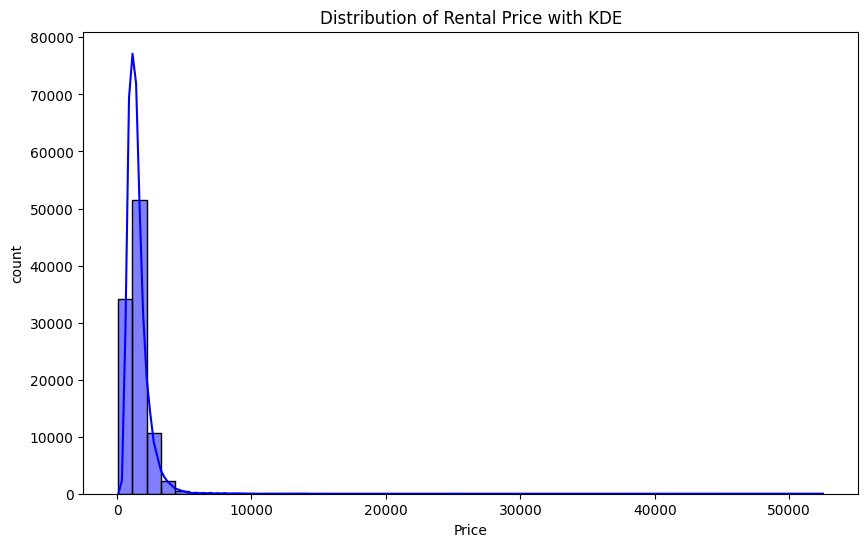

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Rental Price with KDE')
plt.xlabel('Price')
plt.ylabel('count')
plt.show()

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>مدیریت داده‌های پرت</b>
</font>
</h4>

<div dir=rtl>
<font face="B Nazanin" size=4>
ممکن است خانه‌هایی بسیار بزرگ یا بسیار گران باشند یا برعکس، خانه‌‌هایی باشند که بیش از حد ارزان یا کوچک بوده و فاصله‌ی بسیاری با میانگین داشته‌ باشند. در بعضی امور تحلیل داده‌ای، داده‌های پرت می‌توانند نتایج را به نحو نامطلوب تحت تاثیر قرار دهند.
برای مثال، داده‌های پرت می‌توانند باعث غلط‌انداز و یا نامفهوم شدن نمودار‌ها شوند و یا الگوریتم‌های یادگیری ماشین را به اشتباه بیاندازند.
در این قسمت، بعضی از خانه‌هایی که یک یا چند ویژگی پرت یا غیرمعمول دارند را حذف می‌کنیم.
</font>
</p>

<div dir=rtl>
<font face="B Nazanin" size=4>
یکی از روش‌های شناسایی و حذف داده‌های پرت، استفاده از چارک‌ها و نمودار جعبه‌ای می‌باشد.
پس ابتدا نمودار جعبه‌ای ستون قیمت را رسم کنید.
</font>
</p>

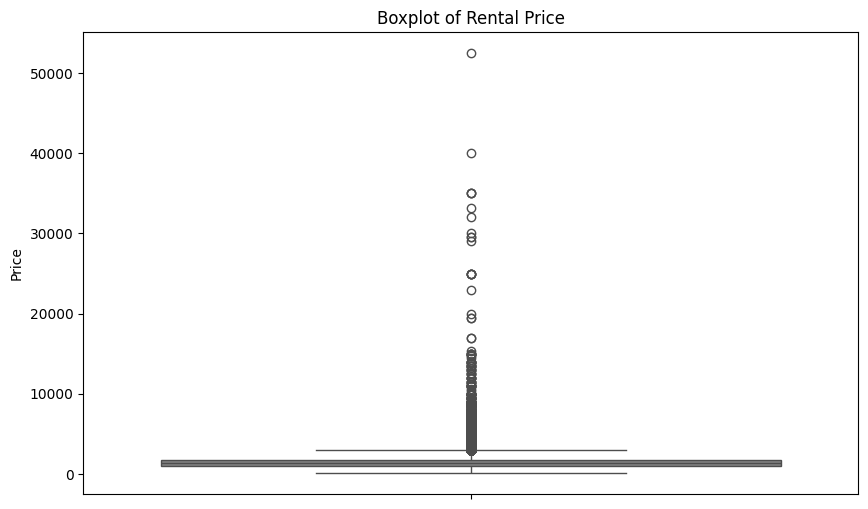

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, y='price', color='gray')
plt.title('Boxplot of Rental Price')
plt.ylabel('Price')
plt.show()

<div dir=rtl>
<font face="B Nazanin" size=4>
در صورتی که نمودار را به درستی رسم کرده باشید مشاهده خواهید کرد که بعضی از داده‌ها آنقدر پرت هستند که نمودار جعبه‌ای از حالت جعبه خارج شده است! نقاطی که در بالای نمودار هستند، داده‌های بسیار پرت می‌باشند.
<br>
داده‌های پرت ستون قیمت را با روش IQR با ضریب 1.5 حذف کنید و نمودار جعبه‌ای را مجددا رسم کنید.
</font>
</p>


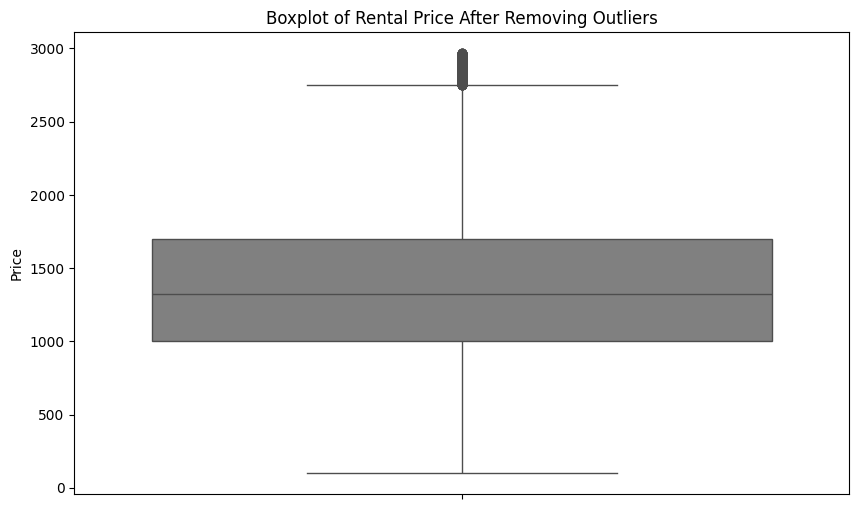

In [16]:

Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['price'] >= lower_bound) & (data['price'] <= upper_bound)]

plt.figure(figsize=(10,6))
sns.boxplot(data=data, y='price', color='gray')
plt.title('Boxplot of Rental Price After Removing Outliers')
plt.ylabel('Price')
plt.show()

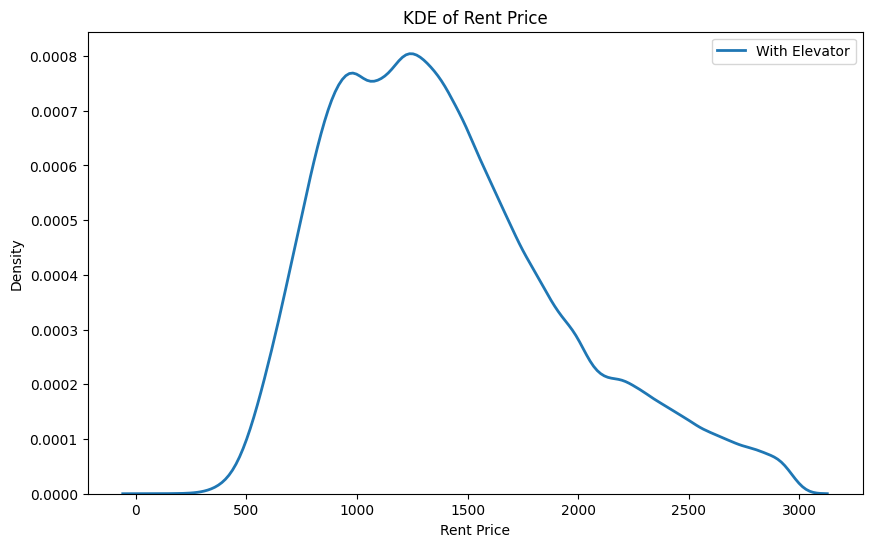

In [17]:
# این تحلیل رو من خودم اضافه کردم
fig, ax = plt.subplots(figsize=(10, 6)) # use this figure and axis to draw the plot


sns.kdeplot(
    data['price'],
    label='With Elevator',
    linewidth=2
)

plt.xlabel('Rent Price')
plt.ylabel('Density')
plt.title('KDE of Rent Price')

plt.legend()
plt.show()

### 🔍 تحلیل نوع گسسته‌سازی برای متغیر "Rent Price"

بر اساس نمودار KDE ارائه‌شده، توزیع داده‌ها **راست‌چوله (Right‑Skewed)** است؛  
یعنی اکثر مقادیر اجاره در محدوده‌ی پایین (حدود 900 تا 1500) متمرکز شده‌اند  
و دنباله‌ای بلند به سمت قیمت‌های بالاتر دیده می‌شود.

---

#### 🧩 گزینه‌های گسسته‌سازی

| نوع گسسته‌سازی | توضیح | مناسب‌تر برای |
|----------------|--------|----------------|
| `pd.cut()` | گسسته‌سازی **بخشی (Equal Width)** — بازه‌ها عرض مساوی دارند اما تعداد داده‌ها در هر بازه متفاوت است. | متغیرهای دارای توزیع یکنواخت یا تفسیرپذیری مبتنی بر مقدار فیزیکی (مثلاً بازه قیمتی واقعی) |
| `pd.qcut()` | گسسته‌سازی **بسامدی (Equal Frequency)** — بازه‌ها طوری تنظیم می‌شوند که تعداد داده‌ها در هر دسته تقریباً برابر باشد. | متغیرهایی با **توزیع چوله یا نامتقارن** برای تحلیل آماری یا مدل‌سازی |

---

#### 📊 وضعیت فعلی
در این توزیع:

- بخش عمده داده‌ها در نواحی با قیمت پایین قرار دارند.  
- چند داده‌ی پرت (outlier) در قیمت‌های بالا وجود دارد.

در نتیجه اگر از `pd.cut()` استفاده شود، بعضی بازه‌ها بسیار پر و بعضی تقریباً خالی خواهند بود.

---

#### ✅ نتیجه‌گیری
برای متغیر **Rent Price** با توزیع راست‌چوله:

> استفاده از **گسسته‌سازی بسامدی (`pd.qcut`)** مناسب‌تر است،  
> زیرا باعث می‌شود داده‌ها به‌صورت متعادل‌تری میان دسته‌ها توزیع شوند  
> و هر دسته تقریباً تعداد برابری از نمونه‌ها داشته باشد.

---

#### 💡 نکته تکمیلی
اگر هدفت تفسیر بازه‌های واقعی قیمت (مثلاً طبقات اقتصادی یا محدوده‌های بازاری) باشد،  
در آن صورت می‌توان از `pd.cut()` با مرزهای معنا‌دار (مثلاً `[0, 1000, 2000, 3000, ∞]`) استفاده کرد.


<div dir=rtl>
<font face="B Nazanin" size=4>
به طور مختصر توضیح دهید که روش IQR چگونه کار می‌کند.
</font>
</p>


<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b> در روش IQR ابتدا داده‌ها به صورت صعودی مرتب می‌شوند. سپس چارک اول (Q1 که نشان‌دهنده ۲۵٪ اول داده‌ها است) و چارک سوم (Q3که نشان‌دهنده ۷۵٪ داده‌ها است) محاسبه می‌شوند و IQR از تفاضل چارک سوم از چارک اول به دست می‌آید:

 IQR = Q3 - Q1 

برای مشخص کردن محدوده مجاز داده‌ها، مرزهای پایین و بالا با استفاده از ضریب استاندارد ۱.۵ محاسبه می‌شوند:

Lower Bound = Q1 - (1.5 × IQR) 

Upper Bound = Q3 + (1.5 × IQR)

در نهایت، هر داده‌ای که مقدار آن کمتر از مرز پایین یا بیشتر از مرز بالا باشد، به عنوان داده پرت شناسایی می‌شود.
</p>
</font>
</div>
</font>
<hr>

<div dir="rtl"> <h2> <font face="B Nazanin" color="#0099cc"> نمونه‌گیری (Sampling) </font> </h2> <font face="B Nazanin" size=4> با توجه به حجم نسبتاً بالای داده (۹۹۳۹۹ رکورد)، برای سرعت بخشیدن به تحلیل‌های بعدی و کاهش زمان محاسباتی، از سه روش مختلف نمونه‌گیری استفاده می‌کنیم: <br><br> <ol> <li><b>نمونه‌گیری تصادفی ساده (Simple Random Sampling):</b> هر رکورد شانس برابری برای انتخاب دارد. این روش ساده‌ترین روش است.</li> <li><b>نمونه‌گیری سیستماتیک (Systematic Sampling):</b> با انتخاب هر دهمین رکورد به صورت منظم انجام می‌شود.</li> <li><b>نمونه‌گیری طبقه‌ای (Stratified Sampling):</b> برای حفظ نسبت شهرهای مختلف در نمونه، از هر شهر به نسبت ۱۰٪ نمونه گرفته می‌شود.</li> </ol> از پارامتر <code>random_state=42</code> استفاده می‌کنیم تا نتایج تکرارپذیر باشند. سپس کیفیت هر سه روش را با ران کردن cell بعدی به طور کامل ارزیابی کنید </font> </div>

In [18]:
# 1. Simple Random Sampling
random_sample = data.sample(frac=0.1, random_state=42)

# 2. Systematic Sampling (every 10th record)
systematic_sample = data.iloc[::10].copy()

# 3. Stratified Sampling 
stratified_samples = []

# Hint: Use groupby('cityname') and loop through groups
# For each group, calculate n_samples = max(1, int(len(group) * 0.1))
for city, group in data.groupby('cityname'):
    n_samples = max(1, int(len(group) * 0.1))
    city_sample = group.sample(n=n_samples, random_state=42)
    stratified_samples.append(city_sample)

stratified_sample = pd.concat(stratified_samples, ignore_index=True)

print(f"Stratified sample size: {len(stratified_sample)}")
print(f"Number of unique cities in sample: {stratified_sample['cityname'].nunique()}")

# Compare Results
print(f"Original data: {len(data):,} records")
print(f"Random sample: {len(random_sample):,} records ({len(random_sample)/len(data)*100:.1f}%)")
print(f"Systematic sample: {len(systematic_sample):,} records")
print(f"Stratified sample: {len(stratified_sample):,} records")



Stratified sample size: 10423
Number of unique cities in sample: 2934
Original data: 94,765 records
Random sample: 9,476 records (10.0%)
Systematic sample: 9,477 records
Stratified sample: 10,423 records


In [19]:
# Compare city proportions for all 3 sampling methods

# Original city proportions
orig_props = data['cityname'].value_counts(normalize=True) * 100

# Proportions for each sample
random_props = random_sample['cityname'].value_counts(normalize=True) * 100
systematic_props = systematic_sample['cityname'].value_counts(normalize=True) * 100
stratified_props = stratified_sample['cityname'].value_counts(normalize=True) * 100

# Create comparison DataFrame
city_comparison = pd.DataFrame({
    'Original_%': orig_props,
    'Random_%': random_props,
    'Systematic_%': systematic_props,
    'Stratified_%': stratified_props
}).fillna(0)

# Calculate differences
city_comparison['Random_Diff'] = city_comparison['Random_%'] - city_comparison['Original_%']
city_comparison['Systematic_Diff'] = city_comparison['Systematic_%'] - city_comparison['Original_%']
city_comparison['Stratified_Diff'] = city_comparison['Stratified_%'] - city_comparison['Original_%']

print("\n" + "="*70)
print("City Proportions Comparison (Top 10 cities)")
print("="*70)
print(city_comparison[['Original_%', 'Random_%', 'Systematic_%', 'Stratified_%']].head(10).round(2))

# Quality metrics for each method
print("\n" + "="*70)
print("Sampling Quality - Average Absolute Difference (%)")
print("="*70)
print(f"Random sampling:      {city_comparison['Random_Diff'].abs().mean():.3f}%")
print(f"Systematic sampling:  {city_comparison['Systematic_Diff'].abs().mean():.3f}%")
print(f"Stratified sampling:  {city_comparison['Stratified_Diff'].abs().mean():.3f}%")

print("\n" + "="*70)
print("Sampling Quality - Maximum Absolute Difference (%)")
print("="*70)
print(f"Random sampling:      {city_comparison['Random_Diff'].abs().max():.3f}%")
print(f"Systematic sampling:  {city_comparison['Systematic_Diff'].abs().max():.3f}%")
print(f"Stratified sampling:  {city_comparison['Stratified_Diff'].abs().max():.3f}%")

# Show which method performs best
best_avg = city_comparison[['Random_Diff', 'Systematic_Diff', 'Stratified_Diff']].abs().mean().idxmin()
best_max = city_comparison[['Random_Diff', 'Systematic_Diff', 'Stratified_Diff']].abs().max().idxmin()
print("\n" + "="*70)
print("Best performer:")
print(f"Lowest average difference: {best_avg.replace('_Diff','')}")
print(f"Lowest maximum difference: {best_max.replace('_Diff','')}")


City Proportions Comparison (Top 10 cities)
           Original_%  Random_%  Systematic_%  Stratified_%
cityname                                                   
Abbeville        0.01      0.01          0.00          0.01
Aberdeen         0.02      0.02          0.01          0.02
Abilene          0.01      0.01          0.00          0.01
Abingdon         0.04      0.05          0.02          0.03
Abington         0.04      0.04          0.02          0.04
Absecon          0.05      0.02          0.05          0.04
Acton            0.02      0.05          0.03          0.02
Acworth          0.01      0.00          0.00          0.01
Addison          0.08      0.07          0.12          0.07
Adelanto         0.01      0.00          0.00          0.01

Sampling Quality - Average Absolute Difference (%)
Random sampling:      0.009%
Systematic sampling:  0.009%
Stratified sampling:  0.009%

Sampling Quality - Maximum Absolute Difference (%)
Random sampling:      0.221%
Systematic samp

<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b> 
</p>
</font>
</div>
</font>
<hr>
<div dir="rtl">

###   ارزیابی کیفیت نمونه‌گیری

در این بخش، کیفیت سه روش نمونه‌گیری با مقایسه **توزیع نسبی شهرها** در نمونه و داده اصلی ارزیابی شد.

#### معیارهای ارزیابی:

$$
\begin{aligned}
\text{میانگین اختلاف مطلق} &= \frac{1}{n}\sum_{i=1}^{n}|\text{نسبت نمونه}_i - \text{نسبت اصلی}_i| \\[0.2cm]
\text{حداکثر اختلاف مطلق} &= \max_{i}|\text{نسبت نمونه}_i - \text{نسبت اصلی}_i|
\end{aligned}
$$

معیار اول (میانگین) نشان‌دهنده **عملکرد کلی** روش در حفظ توزیع است، در حالی که معیار دوم (حداکثر) **پایداری** روش را در بدترین حالت ممکن می‌سنجد.

---

#### تحلیل نتایج:

بر اساس خروجی بالا، نتایج به شرح زیر است:

| روش | میانگین خطا (%) | حداکثر خطا (%) | برنده |
|-----|----------------|---------------|-------|
| **Random** | 0.009 | **0.221** ✅ | پایدارترین |
| **Systematic** | 0.009 | 0.324 | - |
| **Stratified** | **0.009** ✅ | 0.264 | بهترین میانگین |

**نکات کلیدی:**

1. **میانگین خطا یکسان (0.009%)**: هر سه روش در حفظ توزیع کلی شهرها عملکرد یکسانی دارند. این به دلیل **حجم بالای نمونه** (~9,900 رکورد از ~99,000) و **قانون اعداد بزرگ** است که باعث می‌شود تفاوت‌های جزئی در خروجی گرد شده ظاهر نشوند.

2. **Random پایدارترین (حداکثر خطا: 0.221%)**:
   - در نمونه‌گیری تصادفی، احتمال انتخاب هر رکورد مستقل است و **مشکل گرد کردن** وجود ندارد.
   - برای شهرهای بسیار کوچک (مثلاً با 10 رکورد در داده اصلی)، Random می‌تواند 0، 1، 2 یا حتی 3 رکورد انتخاب کند بدون محدودیت ساختاری.

3. **Systematic بدترین حداکثر خطا (0.324%)**:
   - انتخاب هر 10 رکورد یک **الگوی ثابت** ایجاد می‌کند.
   - اگر رکوردهای یک شهر خاص در داده اصلی به صورت خوشه‌ای (clustered) یا با فاصله نامنظم قرار گرفته باشند، این روش می‌تواند آن شهر را **بیش از حد** یا **کمتر از حد** نمونه‌برداری کند.
   - مثال: اگر رکوردهای شهر "Addison" در ردیف‌های 5، 15، 25، ... قرار داشته باشند، ممکن است هیچ‌کدام انتخاب نشوند (چون ما از ردیف‌های 0، 10، 20، ... شروع کرده‌ایم).

4. **Stratified در وسط (حداکثر خطا: 0.264%)**:
   - این روش **تضمین می‌کند** که از هر شهر حداقل 1 رکورد انتخاب شود (به دلیل `max(1, int(len(group) * 0.1))`).
   - اما برای شهرهای بسیار کوچک، **گرد کردن به 1** می‌تواند باعث انحراف نسبی شود.
   - مثال: شهری با 5 رکورد (0.005% از کل) → 1 رکورد در نمونه (0.01% از نمونه) → خطای 0.005% برای آن شهر.

---

#### جمع‌بندی:

$$
\boxed{
\begin{aligned}
&\text{هر سه روش کیفیت بسیار بالایی دارند (میانگین خطا = 0.009\%)} \\[0.2cm]
&\textbf{توصیه:} \\
&\text{• Random: برای پایداری کلی و سادگی پیاده‌سازی} \\
&\text{• Stratified: برای تحلیل‌های مبتنی بر شهر (تضمین حضور همه شهرها)} \\
&\text{• Systematic: برای داده‌های با ترتیب تصادفی (نه خوشه‌ای)}
\end{aligned}
}
$$

**نتیجه نهایی:** با توجه به اینکه Random هم میانگین خطای پایین و هم **کمترین حداکثر خطا** را دارد، این روش برای این مجموعه داده **بهترین انتخاب** است، مگر اینکه نیاز خاصی به تضمین حضور همه شهرها در نمونه داشته باشیم (که در آن صورت Stratified ترجیح دارد).
بنابراین از این به بعد، از random_sample برای تحلیل های بعدی استفاده میکنیم.

---

</div>


<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
گسسته‌سازی (Discretization)
</font>
</h2>
<font face="B Nazanin" size=4>
ویژگی <code>price</code> را به سه دستهٔ «ارزان»، «متوسط» و «گران» تبدیل می‌کنیم. از روش <code>pd.cut</code> با مرزهای منطقی استفاده شده است. این کار برای الگوریتم‌هایی که با دادهٔ گسسته بهتر کار می‌کنند (مثل بعضی مدل‌های درختی یا قوانین association) مفید است.
</font>
</div>

PRICE STATISTICS
count    94765.000000
mean      1402.061858
std        527.182294
min        100.000000
25%        999.000000
50%       1320.000000
75%       1700.000000
max       2968.000000
Name: price, dtype: float64

Skewness: 0.708
Kurtosis: 0.033

DISCRETIZATION BIN RANGES
Low: 297.33  ->  1,189.00
Medium: 1,189.00  ->  2,078.00
High: 2,078.00  ->  2,967.00

PRICE CATEGORY DISTRIBUTION
                Count  Percentage
price_category                   
Low              3702        3.91
Medium           4676        4.93
High             1098        1.16


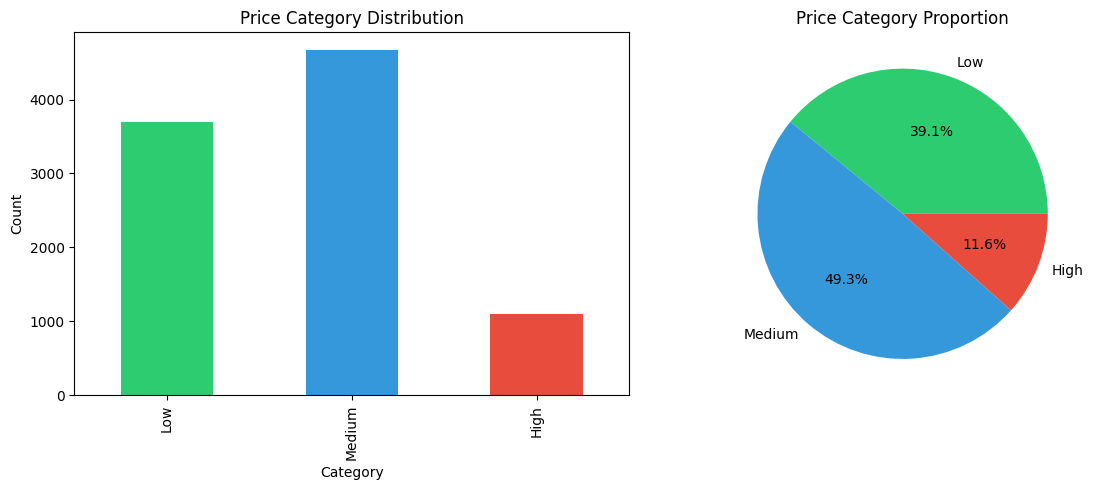


SAMPLE DATA
        price price_category
58217   768.0            Low
77108   845.0            Low
34102   651.0            Low
90004  1557.0         Medium
29284   851.0            Low
23355  1149.0            Low
91308   935.0            Low
84239  1617.0         Medium
31364  1550.0         Medium
34137  1520.0         Medium
2873   2000.0         Medium
9382    944.0            Low
36771   513.0            Low
14750  1445.0         Medium
57765  1056.0            Low


In [20]:
print("="*60)
print("PRICE STATISTICS")
print("="*60)

print(data['price'].describe())
print(f"\nSkewness: {data['price'].skew():.3f}")
print(f"Kurtosis: {data['price'].kurt():.3f}")

# ================================
# Equal Width interval Discretization
# ================================

labels = ['Low', 'Medium', 'High']

random_sample['price_category'] = pd.cut(
    random_sample['price'],
    bins=3,
    labels=labels,
    include_lowest=True
)

# ================================
# Show actual bin boundaries
# ================================
bins = pd.cut(
    random_sample['price'],
    bins=3,
    retbins=True,
    include_lowest=True
)[1]

print("\n" + "="*60)
print("DISCRETIZATION BIN RANGES")
print("="*60)

for i in range(len(bins)-1):
    print(f"{labels[i]}: {bins[i]:,.2f}  ->  {bins[i+1]:,.2f}")


# ================================
# Category distribution
# ================================
print("\n" + "="*60)
print("PRICE CATEGORY DISTRIBUTION")
print("="*60)

counts = random_sample['price_category'].value_counts().sort_index()
percent = (counts / len(data) * 100).round(2)

distribution = pd.DataFrame({
    "Count": counts,
    "Percentage": percent
})

print(distribution)

# ================================
# Visualization
# ================================
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Bar plot
counts.plot(kind='bar', ax=axes[0], color=['#2ecc71','#3498db','#e74c3c'])
axes[0].set_title("Price Category Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#3498db','#e74c3c'])
axes[1].set_title("Price Category Proportion")

plt.tight_layout()
plt.show()

# ================================
# Sample of transformed data
# ================================
print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)

print(random_sample[['price','price_category']].head(15))

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
کاوش در داده‌ها
</font>
</h3>


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>1. همبستگی </b>
</font>
</h4>
<div dir=rtl>
<font face="B Nazanin" size=4>
ماتریس همبستگی (Correlation Matrix) داده‌ها را در قالب یک Heatmap مصور کنید.
</font>
</p>


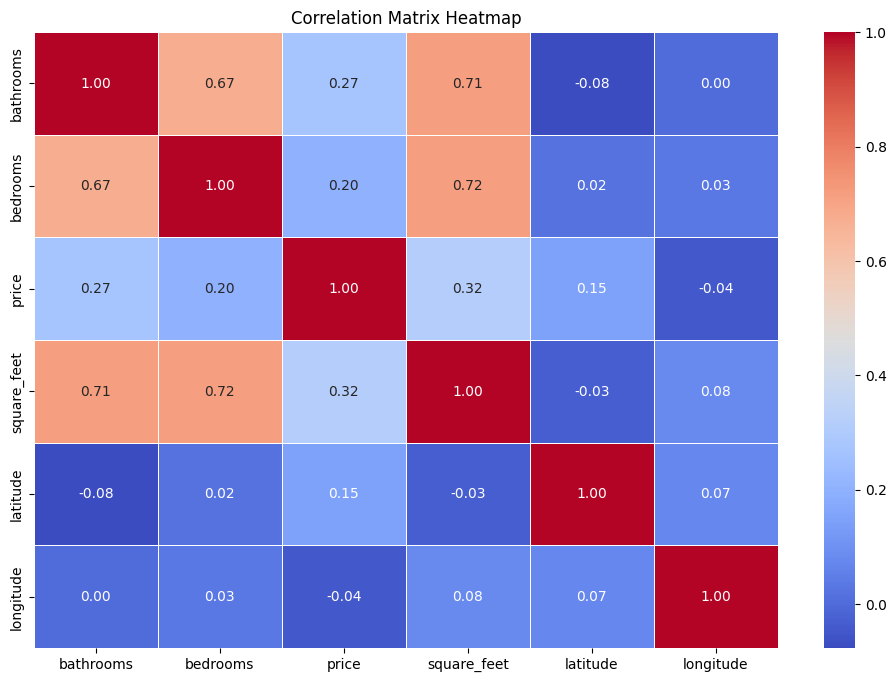

In [21]:
numeric_df = random_sample.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix Heatmap')
plt.show()


<div dir=rtl>
<font face="B Nazanin" size=4>
درمورد نمودار Heatmap و عملکرد آن به طور مختصر توضیح دهید. همچنین تحلیل خود از ویژگی‌هایی که همبستگی بالایی داشتد را نیز به طور خلاصه بنویسید.
</font>
</p>


<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b>   هر درایه در ماتریس HeatMap، ضریب همبستگی پیرسون بین دو ویژگی سطر و ستون آن درایه را با استفاده از شدت رنگ نشان میدهد. برای مثال، در مجموعه داده ای که بررسی کردیم، تعداد اتاق خواب و حمام، با مساحت خانه، بیشترین همبستگی را (آن هم از نوع مستقیم) دارد. بدین معنا که خانه هایی که بزرگتر هستند، معمولا تعداد اتاق و حمام بیشتری نیز دارند.</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>2. تاثیر ایالت بر قیمت </b>
</font>
</h4>

<div dir=rtl>
<font face="B Nazanin" size=4>
در این مجموعه داده، قیمت اجاره و متراژ هر خانه مشخص شده‌است،
اما قیمت اجارهٔ هر فوت مربع خانه مشخص نیست. در ستون
<code>pps</code>
قیمت اجاره خانه‌ها را به ازای هر فوت مربع محاسبه و ذخیره کنید.
</font>
</p>

In [22]:
random_sample['pps'] = random_sample['price']  / random_sample['square_feet']
random_sample['pps'].describe()

count    9476.000000
mean        1.596664
std         0.716408
min         0.198413
25%         1.104716
50%         1.429168
75%         1.908075
max         8.921053
Name: pps, dtype: float64

<div dir=rtl>
<font face="B Nazanin" size=4>
حال می‌خواهیم 10 ایالت با بیشترین میانگین قیمت اجاره بر حسب فوت مربع را بررسی کنیم. این ایالت‌ها را به ترتیب نزولی میانگین قیمت اجاره بر حسب فوت مربع با استفاده از barplot نمایش دهید کنید.
</font>
</p>


<div dir=rtl>
<font face="B Nazanin" size=4>
 می‌توانید از توابع <code>groupby</code> و <code>sort_values</code> استفاده کنید.
</font>
</p>


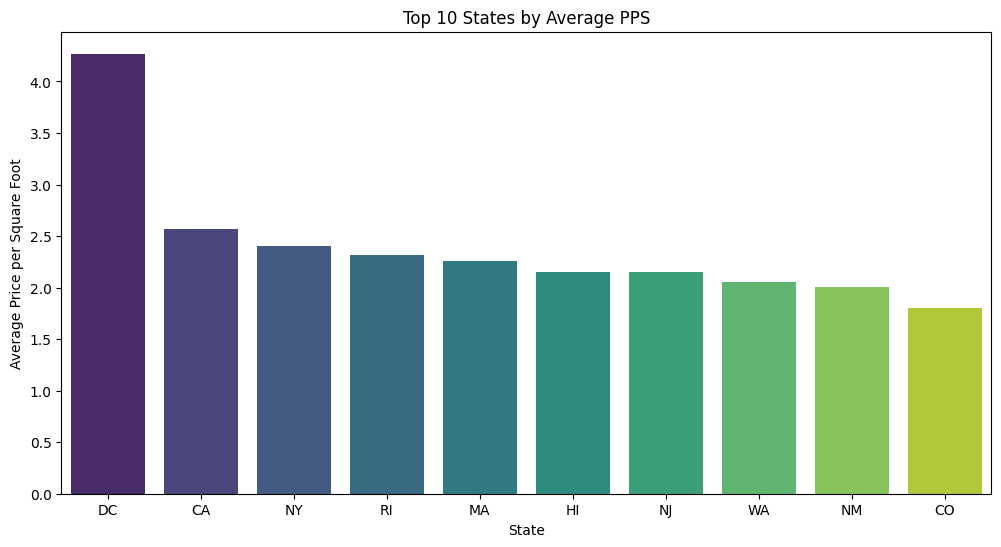

In [23]:
top_states = (
    random_sample.groupby('state')['pps']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values,
    hue=top_states.index,
    palette='viridis',
    legend=False
)

plt.xlabel('State')
plt.ylabel('Average Price per Square Foot')
plt.title('Top 10 States by Average PPS')

plt.show()


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>3. تاثیر فاصله از مرکز شهر بر قیمت </b>
</font>
</h4>

<div dir=rtl>
<font face="B Nazanin" size=4>
در ادامه می‌خواهیم بررسی کنیم که تاثیر فاصله خانه از مرکز شهر بر قیمت اجاره هر فوت مربع خانه چگونه است. بدین منظور شهر دالاس را بررسی خواهیم کرد. ابتدا خانه‌هایی که در شهر دالاس قرار دارند را در یک دیتافریم جدید ذخیره کنید.
</font>
</p>

In [24]:
dallas = random_sample[random_sample['cityname'] == "Dallas"]
dallas.head()

,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude,source,year,month,day_of_week,price_category,pps
63902,"Doorman,Gym,Pool",1.0,1.0,No,Yes,No,1425.0,832,Dallas,TX,32.830481,-96.816958,RentDigs.com,2019,9,1,Medium,1.712740
76695,Parking,2.0,2.0,No,Yes,No,975.0,1059,Dallas,TX,32.672450,-96.904174,RentDigs.com,2019,9,1,Low,0.920680
98253,"Cable or Satellite,Gym,Parking,Patio/Deck,Pool...",2.0,2.0,No,No,"Cats,Dogs",2224.0,1382,Dallas,TX,32.849593,-96.824892,RentDigs.com,2019,9,1,High,1.609262
2054,"AC,Clubhouse,Dishwasher,Fireplace,Gym,Hot Tub,...",2.0,2.0,No,No,No,1510.0,1421,Dallas,TX,32.994461,-96.802485,RentDigs.com,2019,9,1,Medium,1.062632
96836,"Pool,Washer Dryer",2.0,2.0,No,Yes,No,1559.0,1135,Dallas,TX,32.817091,-96.776990,RentDigs.com,2019,9,1,Medium,1.373568


<div dir=rtl>
<font face="B Nazanin" size=4>
با داشتن طول و عرض جغرافیایی خانه‌ها و استفاده از نمودار پراکندگی (Scatter plot) می‌توانیم بررسی را انجام دهیم.
رنگ هر نقطه باید نشان دهنده قیمت اجاره هر فوت مربع خانه باشد و نوار رنگ نشان دهنده قیمت‌های متانظر با طیف رنگی نیز باید در کنار نمودار نمایش داده شود. مختصات مرکز شهر دالاس در زیر آمده است. مرکز شهر را نیز با یک نقطه در نمودار نمایش دهید.
</font>
</p>


$$\text{latitude: } 32.77653 $$
$$\text{longitude: } -96.79708 $$

<div dir=rtl>
<font face="B Nazanin" size=4>
از آنجایی که تعداد نقاط زیاد است، بهتر است سایز نقاط را برابر با 10 قرار دهید تا نقاط بهتر نمایش داده شوند
</font>
</p>


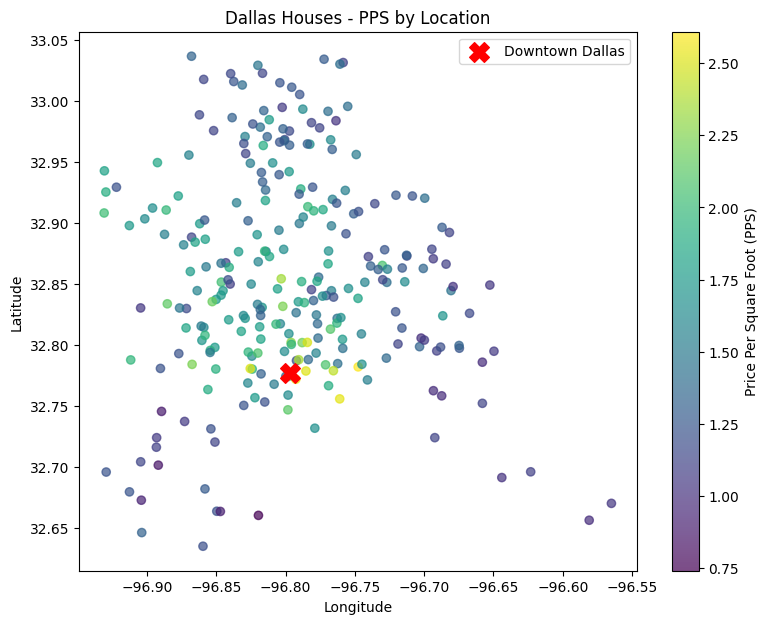

In [25]:
fig, ax = plt.subplots(figsize = (9, 7)) #use this figure and axis to draw plot

scatter = plt.scatter(
    dallas['longitude'],
    dallas['latitude'],
    c=dallas['pps'],
    cmap='viridis',
    alpha=0.7
)

downtown_lat = 32.77653
downtown_lon = -96.79708
plt.scatter(
    downtown_lon,
    downtown_lat,
    color='red',
    s=200,
    marker='X',
    label='Downtown Dallas'
)

cbar = plt.colorbar(scatter)
cbar.set_label('Price Per Square Foot (PPS)')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Dallas Houses - PPS by Location')

plt.legend()

plt.show()


<div dir=rtl>
<font face="B Nazanin" size=4>
می‌توان عکس این منطقه از جهان را پشت نقاط رسم شده قرار داد تا دیدی واقعی‌تر نسبت به محل قرار‌گیری خانه‌ها به‌دست آوریم. با استفاده از محدوده‌ی محور افقی و عمودی نمودار، محدوده‌ی مورد نظر را با استفاده از نقشه‌های گوگل دریافت کرده‌ایم که در عکس <code>dallas.png</code>  ذخیره شده است. با استفاده از متد <code>imshow</code> این عکس را پشت نمودار قرار می‌دهیم.
خروجی مورد انتظار این تصویر است:
</font>
</p>


<p style="text-align:center;"><img src="./images/expected.png" alt="dallas_plot"></p>

In [26]:
import matplotlib.image as mpimg
img = mpimg.imread('images/dallas.png')
ax.imshow(img, extent=[-97, -96.5, 32.55, 33.05], aspect='auto')
fig

FileNotFoundError: [Errno 2] No such file or directory: 'images/dallas.png'

<div dir=rtl>
<font face="B Nazanin" size=4>
برداشت خود را در رابطه با تاثیر فاصله خانه از مرکز شهر بر قیمت اجاره هر فوت مربع خانه بنویسید.
</font>
</p>


<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b> طبق نمودار، بیشترین قیمت های اجاره برای هر فوت مربع، مربوط به مرکز شهر و حوالی آن است. با فاصله گرفتن از مرکز شهر، این مقدار (PPS) برای نواحی جنوبی، سریعتر از نواحی شمالی کاهش می یابد. 
</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>4. تاثیر شهر بر قیمت </b>
</font>
</h4>


<div dir=rtl>
<font face="B Nazanin" size=4>
در این بخش می‌خواهیم بررسی کنیم که در شهرهای مختلف یک ایالت قیمت اجاره هر فوت مربع خانه چگونه است. بدین منظور ایالت کالیفرنیا را بررسی خواهیم کرد. ابتدا خانه‌هایی که در این ایالت قرار دارند را در یک دیتافریم جدید ذخیره کنید.
</font>
</p>

In [ ]:
CA = random_sample[random_sample['state'] == 'CA']
len(CA['price'])

782

<div dir=rtl>
<font face="B Nazanin" size=4>
به منظور نمایش بهتر داده‌ها در نمودار با استفاده از روش IQR با ضریب 1.5 داده‌های پرت را بر حسب ستون <code>pps</code> حذف کنید.
</font>
</p>

In [ ]:
Q1 = CA['pps'].quantile(0.25)
Q3 = CA['pps'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

CA = CA[(CA['pps'] >= lower_bound) & (CA['pps'] <= upper_bound)].copy()
print(len(CA['price']))

772


<div dir=rtl>
<font face="B Nazanin" size=4>
حال با نمودار Scatter plot مشابه بخش قبل داده‌ها را نمایش دهید.
تصویر <code>CA.png</code> شامل نقشه بخشی از ایالت کالیفرنیا می‌باشد که محدوده آن در زیر آمده است.
</font>
</p>

$$\text{latitude: } 33.0391 \rightarrow 38.7586$$
$$\text{longitude: }-123.6021 \rightarrow  -116.5354$$

<div dir=rtl>
<font face="B Nazanin" size=4>
توجه شود که در این بخش علاوه بر مشخص کردن محدوده تصویر، محدوده کلی نمودار را نیز باید به مختصات‌های گفته شده محدود کنید زیرا داده‌های ما شامل تمام داده‌های ایالت کالیفرنیا می‌باشد و در صورتی که محدوده نمودار مشخص نشود، داده‌های خارج از محدوده نقشه نیز نمایش داده خواهند شد.
</font>
</p>


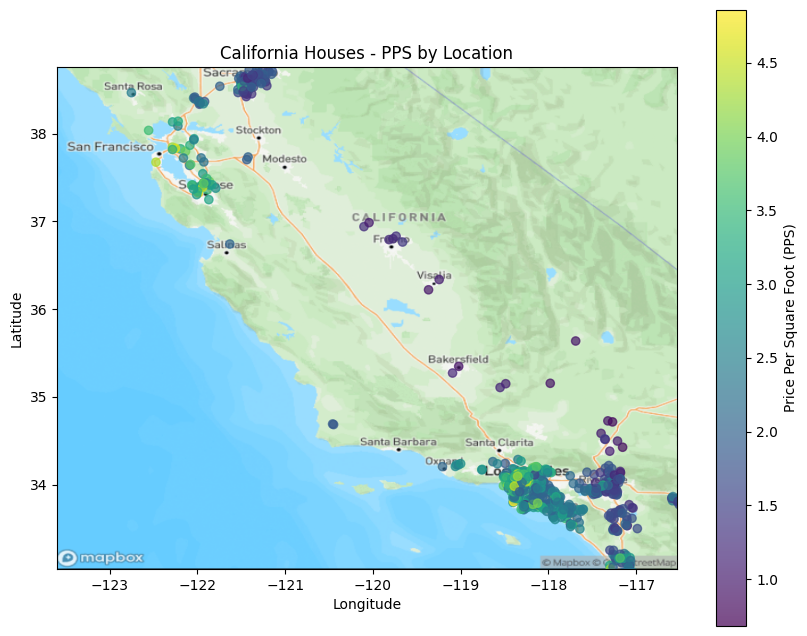

In [ ]:
fig, ax = plt.subplots(figsize = (10, 8)) #use this figure and axis to draw plot

img = mpimg.imread('images/CA.png')
ax.imshow(
    img,
    extent=[-123.6021, -116.5354, 33.0391, 38.7586],
    aspect='equal'
)

scatter = ax.scatter(
    CA['longitude'],
    CA['latitude'],
    c=CA['pps'],
    cmap='viridis',
    alpha=0.7
)


cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Price Per Square Foot (PPS)')

ax.set_xlim(-123.6021, -116.5354)
ax.set_ylim(33.0391, 38.7586)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('California Houses - PPS by Location')

plt.show()

<div dir=rtl>
<font face="B Nazanin" size=4>
برداشت خود را در رابطه با تاثیر شهر بر قیمت اجاره هر فوت مربع خانه بنویسید.
</font>
</p>


<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b> با بررسی نقشه مشاهده می‌شود که شاخص PPS در شهرهای بزرگ و پرتقاضای کالیفرنیا مانند San Francisco، San Jose، Los Angeles و San Diego به‌طور محسوسی بالاتر است. در مقابل، شهرهای مرکزی و نواحی دور از مراکز اقتصادی (مانند Fresno، Bakersfield و مناطق داخلی) PPS بسیار پایین‌تری دارند. بنابراین می‌توان نتیجه گرفت که شهر نقش مهمی در تعیین قیمت هر فوت مربع دارد؛ به‌طوری‌که شهرهای ساحلی و کلان‌شهرها به دلیل تقاضای بالا، تراکم اقتصادی و سطح درآمد بالاتر، قیمت بیشتری دارند و به طور کلی میتوان گفت که شاخص PPS برای شهرهای ساحلی ایالت کالیفرنیا بیشتر است و میتوان گفت با فاصله گرفتن از ساحل، این شاخص کاهش میابد.
</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>5. رابطه بین متراژ و قیمت </b>
</font>
</h4>


<div dir=rtl>
<font face="B Nazanin" size=4>
با استفاده از نمودار توام (Joint plot) رابطه بین متراژ خانه و قیمت اجاره خانه در شهر دالاس را بررسی کنید.
</font>
</p>

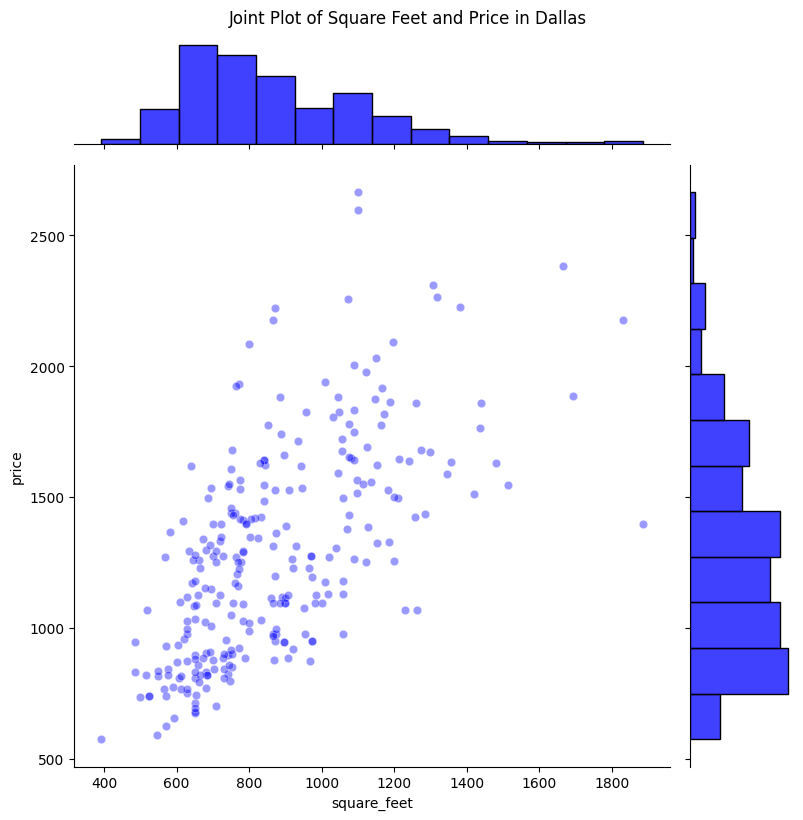

In [ ]:
Dallas = random_sample[random_sample['cityname'] == 'Dallas']

sns.jointplot(
    data=dallas,
    x='square_feet',
    y='price',
    kind='scatter',
    alpha=0.4,
    height=8,
    color='blue'
)

plt.suptitle('Joint Plot of Square Feet and Price in Dallas', y=1.02)
plt.show()

<div dir=rtl>
<font face="B Nazanin" size=4>
برداشت شما از نمودار چیست؟ همچنین در رابطه با نحوه‌ی رسم این نمودار و کاربرد‌های آن توضیح دهید.
</font>
</p>


<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b> نمودار Joint Plot نشان می‌دهد که بین متراژ خانه و قیمت اجاره در دالاس یک رابطه مثبت وجود دارد؛ یعنی هرچه متراژ (square_feet) افزایش پیدا می‌کند، قیمت (price) نیز تمایل به افزایش دارد. با این حال پراکندگی نقاط نشان می‌دهد متراژ تنها عامل مؤثر بر قیمت نیست و عوامل دیگری مثل موقعیت و امکانات نیز تأثیر دارند.
<br><br>
<b>نحوه رسم نمودار:</b><br>
در این نمودار، محورهای اصلی پراکندگی رابطه بین دو متغیر را نشان می‌دهند، و دو هیستوگرام در بالا و راست، توزیع جداگانه هر متغیر را نمایش می‌دهند. این ترکیب باعث می‌شود هم رابطه دوجانبه و هم رفتار تک‌متغیره داده‌ها در یک نمودار دیده شود.
<br><br>
<b>کاربردهای نمودار:</b><br>
• بررسی رابطه بین دو ویژگی کمی مثل متراژ و قیمت  
• تشخیص روند کلی (مثبت، منفی یا نبود رابطه)  
• مشاهده نقاط پرت یا الگوهای غیرمعمول  
• تحلیل توزیعی هر ویژگی به صورت هم‌زمان  
• کاربرد زیاد در تحلیل داده‌های مسکن، اقتصاد، سلامت و یادگیری ماشین
</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>6. تاثیر آسانسور بر قیمت</b>
</font>
</h4>


<div dir=rtl>
<font face="B Nazanin" size=4>
در این بخش می‌خواهیم تاثیر آسانسور بر قیمت اجاره خانه را بررسی کنیم. با نمودار Kdeplot توزیع قیمت اجاره خانه‌هایی که دارای آسانسور هستند و خانه‌هایی که آسانسور ندارند را بررسی کنید.
<br>
وجود یا عدم وجود آسانسور باید از ستون <code>amenities</code> استخراج شود. در صورتی که خانه‌ای دارای آسانسور باشد در ستون <code>amenities</code> عبارت <code>Elevator</code> وجود دارد.
</font>
</p>


<div dir=rtl>
<font face="B Nazanin" size=4>
نمودار Kdeplot هر دو دسته را در یک Axes نمایش دهید.
</font>
</p>


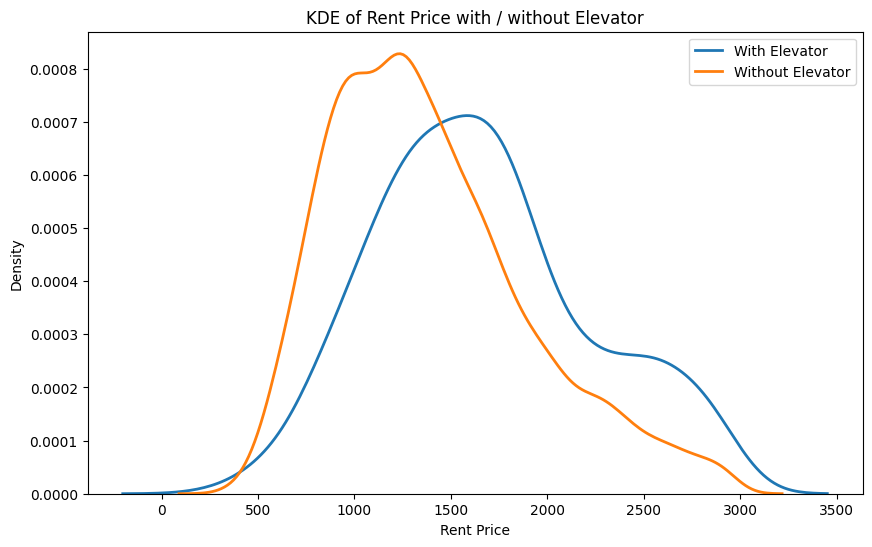

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6)) # use this figure and axis to draw the plot

has_elevator = random_sample[random_sample['amenities'].astype(str).str.contains('Elevator', case=False, na=False)]
has_no_elevator = random_sample[~random_sample['amenities'].astype(str).str.contains('Elevator', case=False, na=False)]

sns.kdeplot(
    has_elevator['price'],
    label='With Elevator',
    linewidth=2
)

sns.kdeplot(
    has_no_elevator['price'],
    label='Without Elevator',
    linewidth=2
)

plt.xlabel('Rent Price')
plt.ylabel('Density')
plt.title('KDE of Rent Price with / without Elevator')

plt.legend()
plt.show()

<div dir=rtl>
<font face="B Nazanin" size=4>
برداشت خود را در رابطه با تاثیر آسانسور بر قیمت اجاره خانه بنویسید.
</font>
</p>


<font face="B Nazanin">
<div dir="rtl">
<p align="justify"><font size="4">
<b><font color="#eb4034">توضیحات پاسخ:</font></b>
با توجه به نمودار KDE، می‌توان مشاهده کرد که توزیع قیمت اجاره برای خانه‌های دارای آسانسور (نمودار آبی) به طور واضحی به سمت قیمت‌های بالاتر جابه‌جا شده است. در حالی که بیشترین تراکم خانه‌های بدون آسانسور (نمودار نارنجی) در بازه‌های قیمتی پایین‌تر (حدود 1200-1300 واحد) قرار دارد، خانه‌های دارای آسانسور عمدتاً در بازه قیمتی بالاتر (حدود 1600-1700 واحد) متمرکز هستند. 
به علاوه، حضور آسانسور در خانه‌های گران‌قیمت‌تر (انتهای سمت راست نمودار) بسیار بیشتر است. در نتیجه، می‌توان نتیجه گرفت که وجود آسانسور به عنوان یک امکان رفاهی مهم، همبستگی مثبت با افزایش قیمت اجاره داشته و به طور معمول یکی از ویژگی‌های ملک‌های گران‌تر محسوب می‌شود.
</font></p>
</div>
</font>
<hr>


<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>7. بررسی توزیع قیمت</b>
</font>
</h4>


<div dir=rtl>
<font face="B Nazanin" size=4>
در این بخش می‌خواهیم توزیع قیمت اجاره خانه‌ها در دو ایالت واشنگتون و تگزاس را بررسی کنیم. برای این کار ابتدا خانه‌هایی که در این دو ایالت قرار دارند را در یک دیتافریم جدید ذخیره کنید و سپس با نمودار ویالنی (Violin plot) توزیع قیمت اجاره خانه‌ها را برای این دو ایالت نمایش دهید.
</font>
</p>


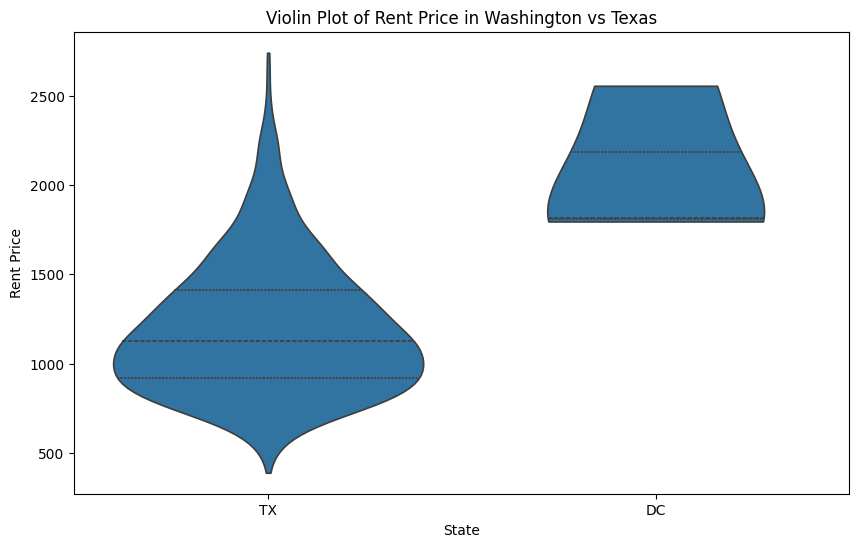

In [ ]:
filtered_df = random_sample[random_sample['state'].isin(['DC', 'TX'])]


fig, ax = plt.subplots(figsize=(10, 6)) #use this figure and axis to draw plot

sns.violinplot(
    data=filtered_df,
    x='state',
    y='price',
    inner='quartile',   
    cut=0
)

plt.xlabel('State')
plt.ylabel('Rent Price')
plt.title('Violin Plot of Rent Price in Washington vs Texas')
plt.show()


<div dir=rtl>
<font face="B Nazanin" size=4>
تحلیل خود از نمودار را بنویسید. همچنین توضیح دهید که نمودار ویالنی برای تحلیل بصری در چه مواقعی مناسب است.
</font>
</p>


<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b>  نمودار ویالنی نشان می‌دهد که توزیع قیمت اجاره در دو ایالت تگزاس (TX) و واشنگتن دی‌سی (DC) تفاوت قابل توجهی دارد. خانه‌های موجود در DC معمولاً در سطح قیمتی بالاتری قرار دارند؛ میانه‌ی قیمت و بخش ضخیم‌تر ویالن در DC به‌وضوح در بازه‌های بالاتری قرار گرفته است. این موضوع بیان می‌کند که اجاره مسکن در DC به طور میانگین بیشتر از تگزاس است. در مقابل، توزیع قیمت در تگزاس گسترده‌تر و بیشتر در محدوده‌ی قیمت‌های پایین‌تر متمرکز است. قله‌ی اصلی ویالن تگزاس در حوالی بازه‌ی ۹۰۰ تا ۱۳۰۰ واحد قرار دارد، در حالی که در DC این مقدار به حدود  ۲۰۰۰ واحد منتقل شده است. این تفاوت‌ها نشان می‌دهد که بازار اجاره مسکن در DC لوکس‌تر و گران‌تر است.

نمودار ویالنی (Violin Plot) زمانی مناسب است که بخواهیم
هم‌زمان شکل توزیع داده (چگالی، چندقله‌ای بودن و پهنای توزیع) را ببینیم و هم مثل Boxplot ،اطلاعات آماری کلیدی مانند میانه و چارک‌ها را مشاهده کنیم. این نمودار به‌ویژه برای مقایسه‌ی چند گروه (مانند دو ایالت، دو دسته کاربر، دو کلاس) بسیار قدرتمند است.
</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<h4>
<font face="B Nazanin">
<b>8. تاثیر استاندارد سازی</b>
</font>
</h4>


<div dir=rtl>
<font face="B Nazanin" size=4>
در این بخش می‌خواهیم تاثیر استاندارد سازی بر ویژگی‌ها را بررسی کنیم. در تصویر زیر نمودار پراکندگی برای دو ویژگی <code>price</code> و <code>bedrooms</code> رسم شده است.
همانطور که مشاهده می‌کنید در صورتی که بازه نمودار در هر دو محور را یکسان در نظر بگیریم، اطلاعات مفیدی از نمودار قابل برداشت نمی‌باشد.
<br>
یک کپی از دیتافریم بگیرید و در دیتافریم جدید این دو ویژگی را استاندارد کنید و سپس نمودار را مجددا رسم کنید.
</font>
</p>
<p style="text-align:center;"><img src="./images/scatter.png" alt="Scatter Plot", width=700></p>


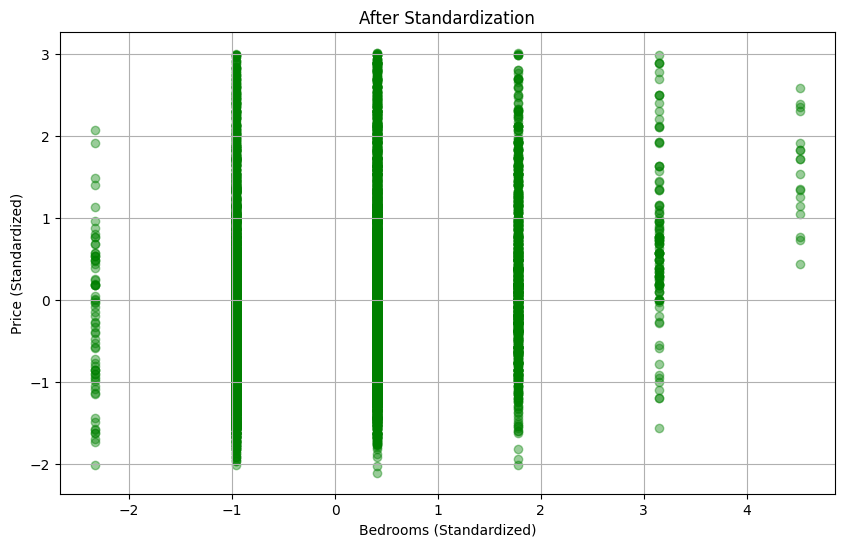

In [ ]:
data_copy = random_sample.copy()

data_copy['price'] = (random_sample['price'] - random_sample['price'].mean()) / random_sample['price'].std()
data_copy['bedrooms'] = (random_sample['bedrooms'] - random_sample['bedrooms'].mean()) / random_sample['bedrooms'].std()

plt.figure(figsize=(10, 6))
plt.scatter(data_copy['bedrooms'], data_copy['price'], alpha=0.4, color='green')
plt.xlabel('Bedrooms (Standardized)')
plt.ylabel('Price (Standardized)')
plt.title('After Standardization')
plt.grid(True)
plt.show()


<div dir=rtl>
<font face="B Nazanin" size=4>
استاندارد سازی چه تاثیری بر نمودار داشت؟ همچنین به طور مختصر بررسی کنید که استاندارد‌سازی ویژگی‌ها چگونه می‌تواند باعث بهبود الگوریتم‌های یادگیری ماشین شود.
</font>
</p>


<font face="B Nazanin">
<div dir=rtl>
<p align="justify">
<font size=4>
<b> <font color='#eb4034'> توضیحات پاسخ: </font></b>  تأثیر استانداردسازی بر نمودار:
در نمودار اولیه، به دلیل تفاوت بسیار زیاد در مقیاس دو ویژگی «قیمت» (در مقایس هزار) و «تعداد اتاق‌خواب» (در بازه 1 تا 5)، پراکندگی داده‌ها قابل مشاهده نبود و بیشتر نقاط به صورت فشرده در یک ناحیه قرار می‌گرفتند. پس از استانداردسازی، هر دو ویژگی به مقیاسی مشابه منتقل شدند (میانگین برابر صفر و انحراف معیار برابر یک). این موضوع باعث شد شکل واقعی پراکندگی داده‌ها آشکار شود و رابطه میان دو ویژگی با وضوح بیشتری قابل مشاهده باشد. به عبارت دیگر، استانداردسازی باعث شد تأثیر تفاوت‌های مقیاسی حذف شود و نمودار اطلاعات معنی‌دار و قابل تحلیلی ارائه دهد.

استانداردسازی باعث می‌شود همه ویژگی‌ها در یک مقیاس قرار بگیرند و این موضوع برای بسیاری از الگوریتم‌های یادگیری ماشین ضروری است. الگوریتم‌هایی که به فاصله حساس‌اند مثل KNN و K-Means، بدون استانداردسازی عملکرد ضعیفی دارند چون ویژگی‌های بزرگ‌تر اثر بیشتری می‌گذارند. همچنین در مدل‌های مبتنی بر گرادیان مثل رگرسیون لجستیک و شبکه‌های عصبی، استانداردسازی باعث می‌شود مدل سریع‌تر و پایدارتر آموزش ببیند. در مدل‌هایی مثل PCA نیز استانداردسازی از تسلط ویژگی‌های بزرگ جلوگیری می‌کند و ساختار واقعی داده را بهتر آشکار می‌سازد.
</p>
</font>
</div>
</font>
<hr>

<div dir=rtl>
<h2>
<font face="B Nazanin" color="#0099cc">
بخش امتیازی

<div dir=rtl>
<font face="B Nazanin" size=4>
در مورد روش حذف مقادیر پرت به کمک معیار Z-score مطالعه کنید.
     برای ویژگی <code>price</code> قبل‌تر از طریق روش IQR مقادیر پرت را حذف کرده بودیم، این بار با استفاده از روش Z-score مقادیر پرت را با آستانه Z = ±3
     حذف کنید.
     برای حذف مقادیر پرت، از توابع آماده‌ای که مستقیما Z-score را محاسبه می‌کنند استفاده نکنید.
</div>
</font>
